In [277]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

Train data

In [278]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage Pb')

In [279]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb2-4-0.jpg,1.742877,8.028072,13.920142,2.512267
1,rl1_pb2-4-1.jpg,0.633193,7.097788,13.573837,3.012700
2,rl1_pb2-4-10.jpg,0.631462,7.461026,13.752362,3.065315
3,rl1_pb2-4-11.jpg,0.983420,7.352412,13.720861,3.165868
4,rl1_pb2-4-12.jpg,2.035994,8.312645,13.933101,2.089599
...,...,...,...,...,...
1553,rl4_pb8-7-59.jpg,1.497187,11.203548,50.611644,4.333491
1554,rl4_pb8-7-6.jpg,1.346369,10.769154,50.762674,4.592259
1555,rl4_pb8-7-7.jpg,2.164350,10.603742,50.729112,4.624104
1556,rl4_pb8-7-8.jpg,0.551839,10.672998,50.418923,4.438358


In [280]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [281]:
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])

In [282]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [283]:
fft_features.shape

(1558, 400)

In [284]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((1558,), (1558,), (1558,), (1558,))

In [285]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [286]:
labels.shape

(1558, 4)

SVM with FFT and PCA

In [287]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

Linear Regression with FFT and PCA

In [288]:
lr = LinearRegression()
mlr = MultiOutputRegressor(lr)
mlr.fit(fft_features, labels)

MultiOutputRegressor(estimator=LinearRegression())

XGBoost with FFT and PCA

In [289]:
xgb = XGBRegressor()
mxgb = MultiOutputRegressor(xgb)
mxgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...))

Catboost with FFT and PCA

In [290]:
cbr = cb.CatBoostRegressor()
mcb = MultiOutputRegressor(cbr)
mcb.fit(fft_features, labels, verbose=False)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x000001FE83A8A6D0>)

Random Forest with FFT and PCA

In [291]:
rf = RandomForestRegressor()
mrf = MultiOutputRegressor(rf)
mrf.fit(fft_features, labels)

MultiOutputRegressor(estimator=RandomForestRegressor())

test data

In [292]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage Pb')

In [293]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl3_pb2-4-0.jpg,0.555155,4.413176,24.913197,1.888317
1,rl3_pb2-4-1.jpg,0.736215,5.437606,24.644843,2.155343
2,rl3_pb2-4-10.jpg,1.907526,5.145160,24.829110,1.322044
3,rl3_pb2-4-11.jpg,1.757560,4.999636,24.674980,1.350174
4,rl3_pb2-4-12.jpg,1.681842,4.850995,24.774774,1.556819
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,3.398249,7.212283,58.217262,2.567910
386,rl4_pb30-6-61.jpg,2.808150,6.702958,57.796025,1.613571
387,rl4_pb30-6-7.jpg,2.302104,6.933498,57.982724,1.255322
388,rl4_pb30-6-8.jpg,2.969147,6.851764,57.977263,2.124009


In [294]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [295]:
for line in df_test.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_cu.append(line[1])
    test_labels_fe.append(line[2])
    test_labels_pb.append(line[3])
    test_labels_zn.append(line[4])

In [296]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [297]:
test_fft_features.shape

(390, 400)

In [298]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [299]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [300]:
test_labels.shape

(390, 4)

SVM

In [301]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.470006772642483
MSE 69.21862080394257
R2 Score 0.03764699642544722


In [302]:
pickle.dump(msvm, open("./models/svm_model", 'wb'))

XGBoost

In [303]:
y_pred = mxgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.682758754870394
MSE 57.64731819749824
R2 Score 0.10509209608604159


In [304]:
pickle.dump(mxgb, open("./models/xgboost_model", 'wb'))

Linear Regression

In [305]:
y_pred = mlr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.87423899921726
MSE 61.34195339473774
R2 Score 0.05557360218983359


In [306]:
pickle.dump(mlr, open("./models/linear_regression_model", 'wb'))

Catboost

In [307]:
y_pred = mcb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.475175390200228
MSE 48.53928736553788
R2 Score 0.18609083718371283


In [308]:
pickle.dump(mcb, open("./models/catboost_model", 'wb'))

Random Forest

In [309]:
y_pred = mrf.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.5053185985161575
MSE 47.43918896485955
R2 Score 0.19021281518398817


In [310]:
pickle.dump(mrf, open("./models/random_forest_model", 'wb'))

# Test Video #1

In [37]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "DataSource.xlsx")

SVM

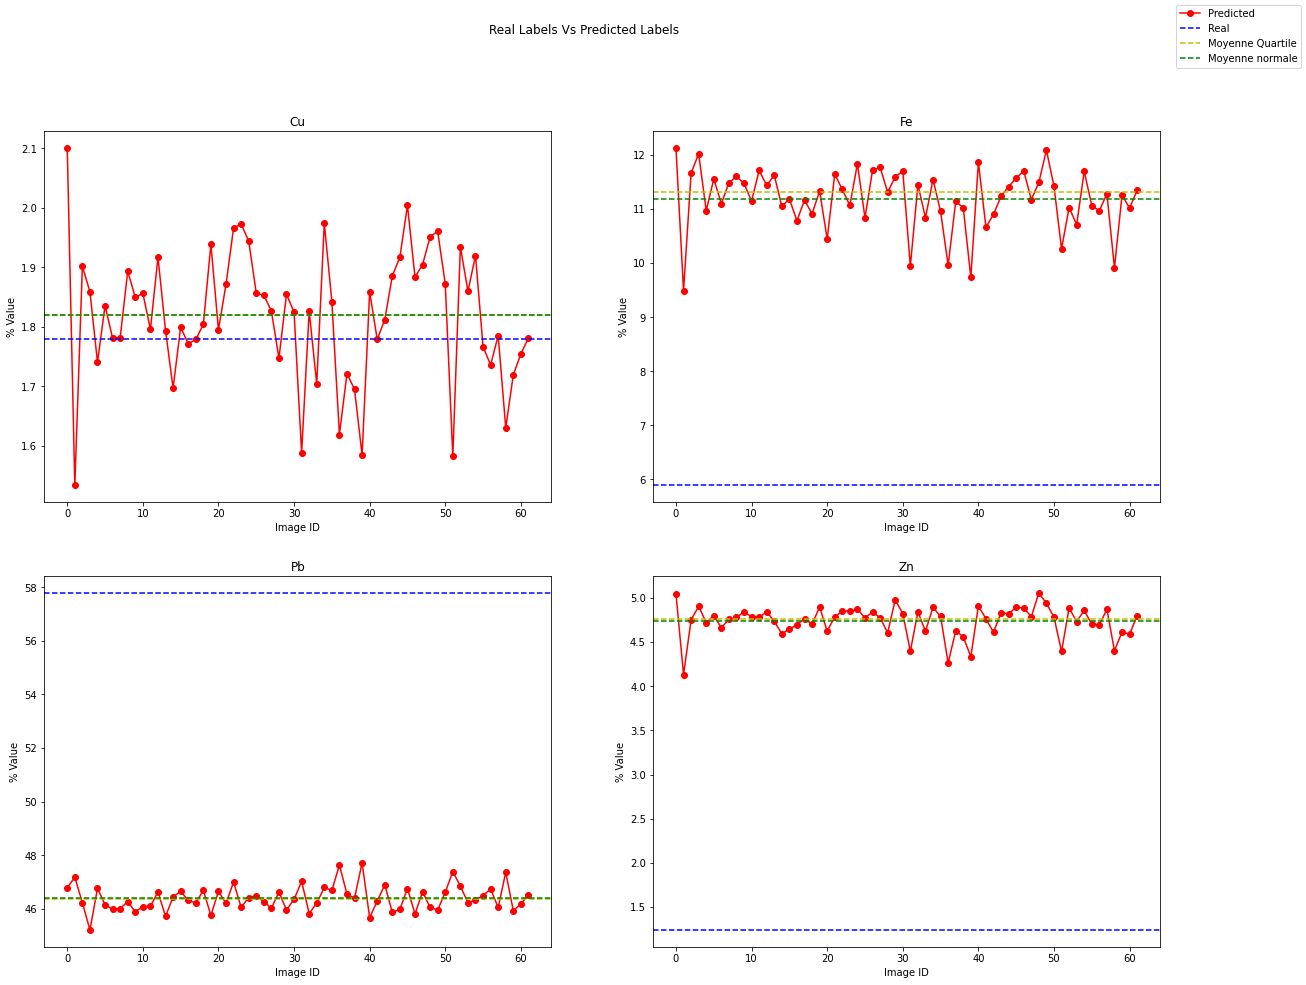

In [38]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [39]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.03944225451062433
Fe: 5.421453908002902
Pb: 11.427904694700409
Zn: 3.52294256448127


Random Forest

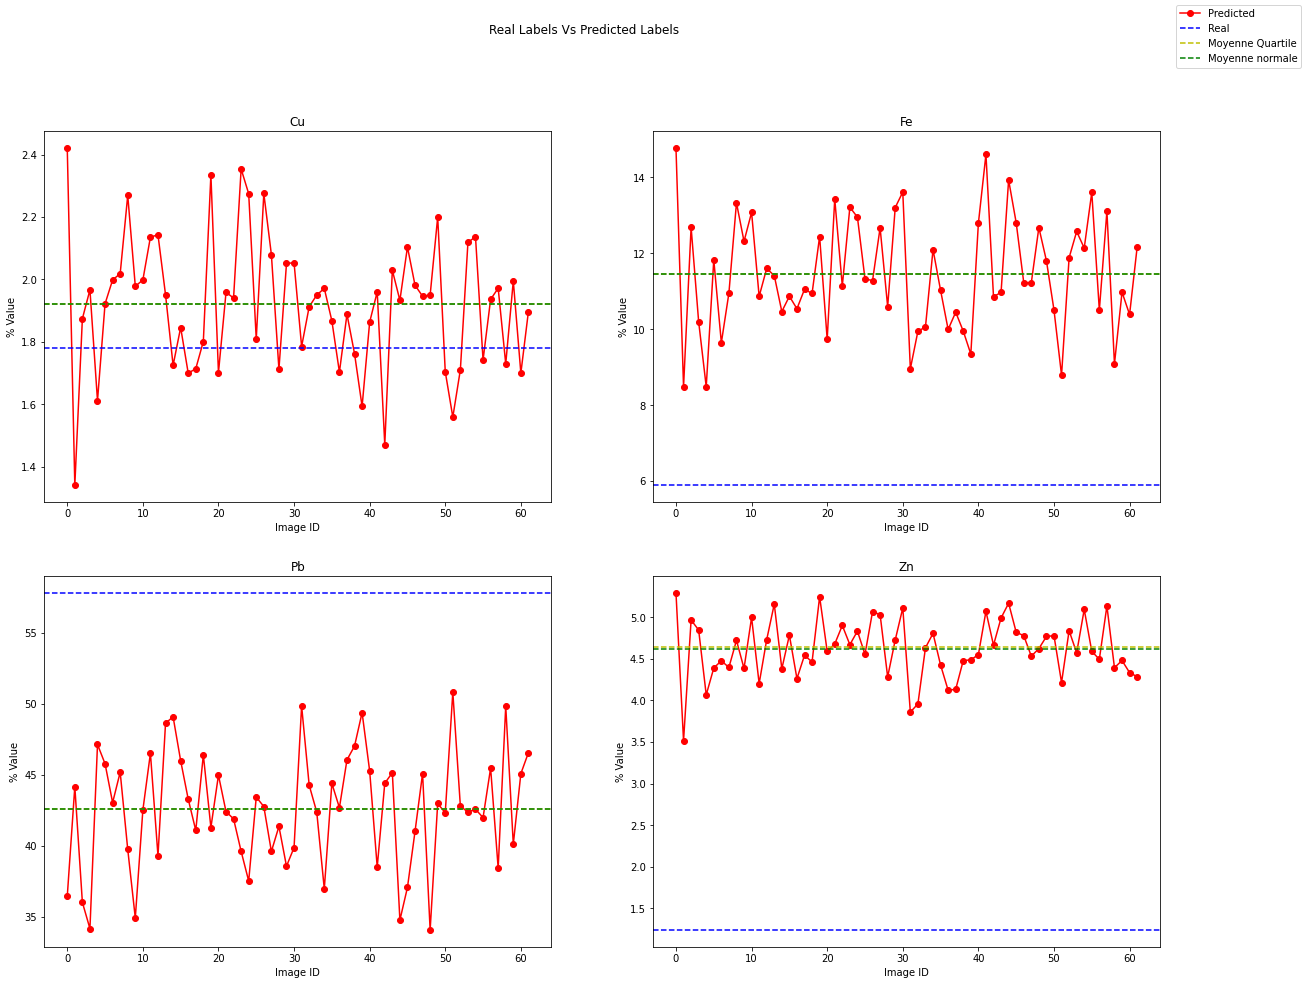

In [40]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [41]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.1400099977812257
Fe: 5.555552897467021
Pb: 15.162581319907126
Zn: 3.396447933830407


XGBoost

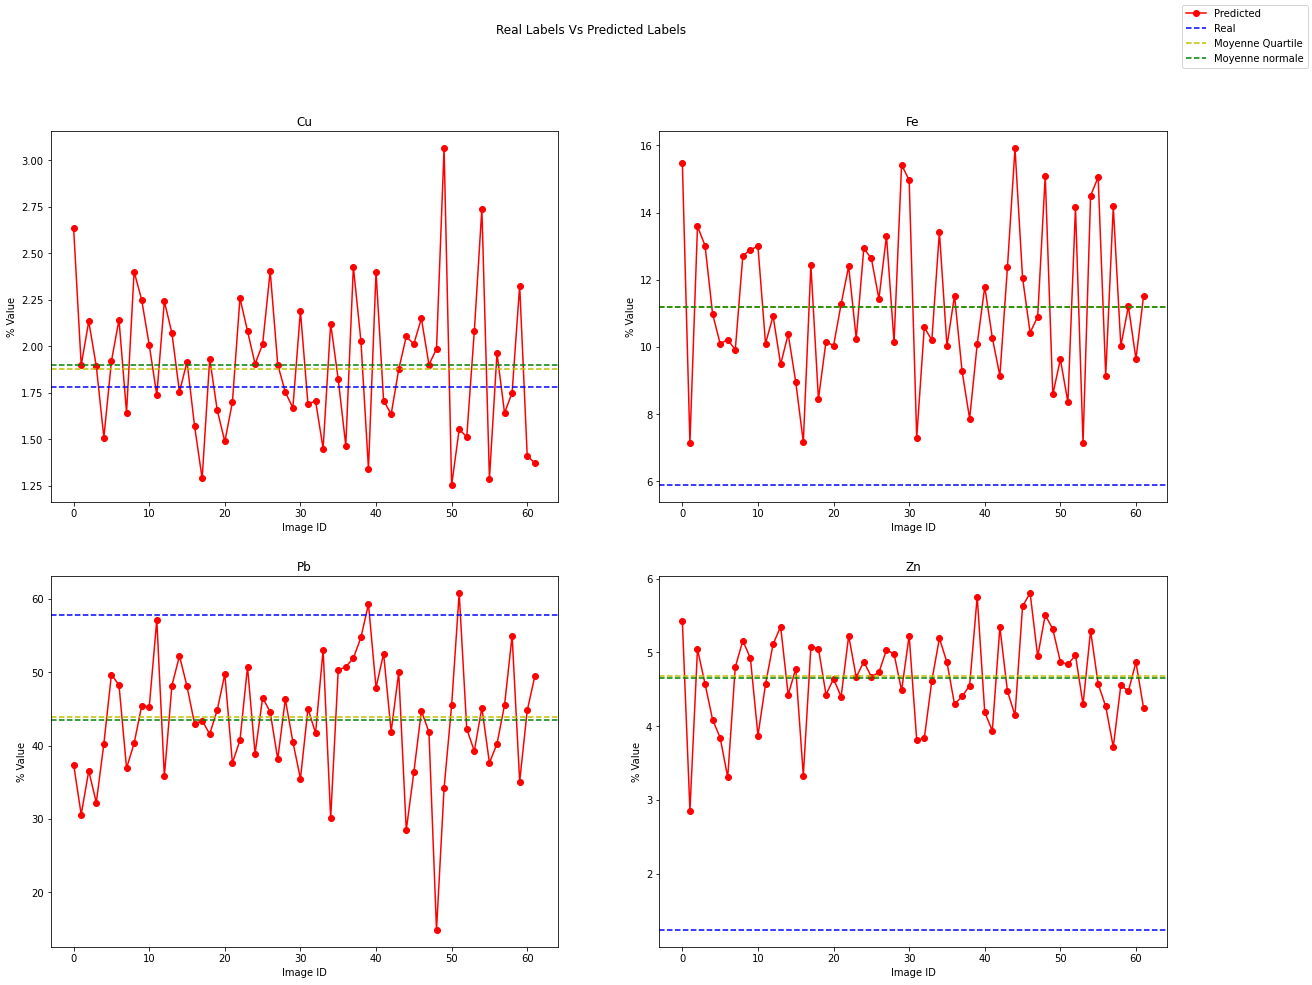

In [42]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [43]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.09867724895477292
Fe: 5.293023452758789
Pb: 13.81005599975586
Zn: 3.4433119392395017


Catboost

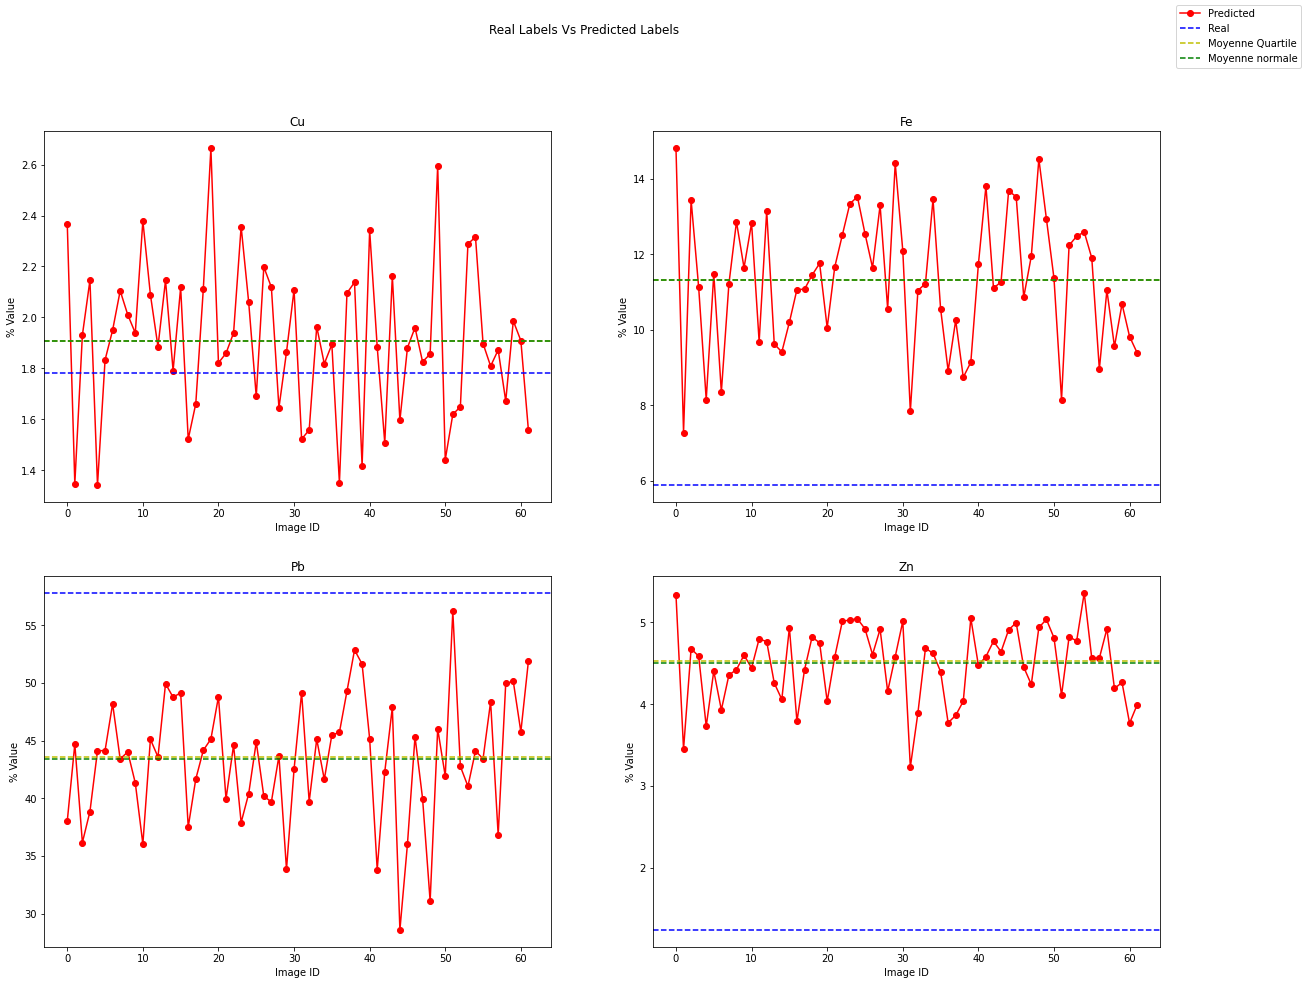

In [44]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [45]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.12935118272612578
Fe: 5.417689978176656
Pb: 14.15880546411968
Zn: 3.284202456946473


# Test Video #2

In [46]:
TeunneurReel = TenneurReel("rl4_pb12-4.mp4", "DataSource.xlsx")

SVM

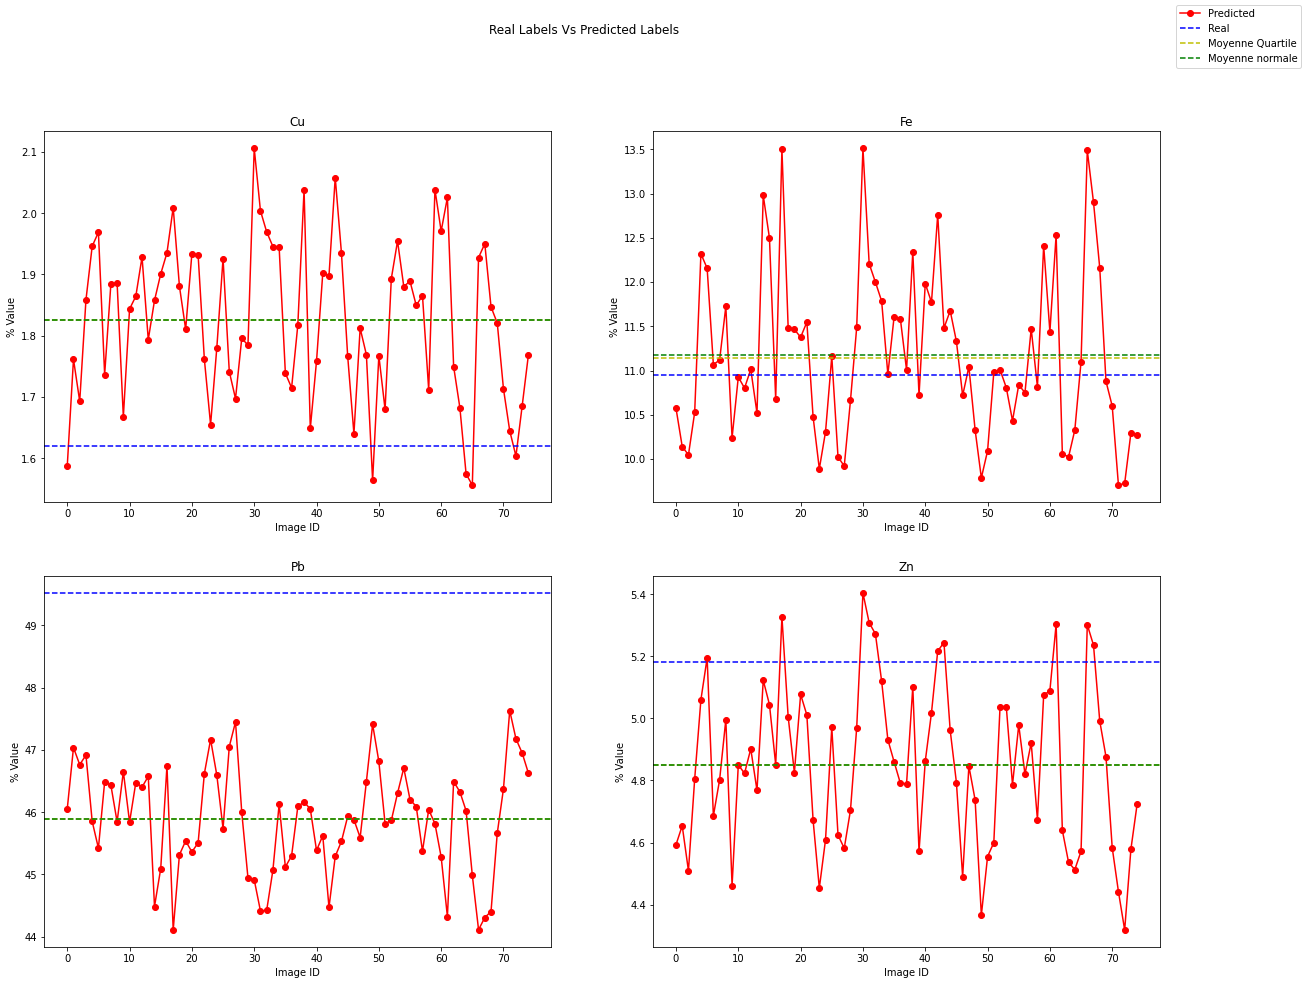

In [47]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [48]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.2054407119513575
Fe: 0.1962971948173724
Pb: 3.6344655174068947
Zn: 0.3289992827536281


Random Forest

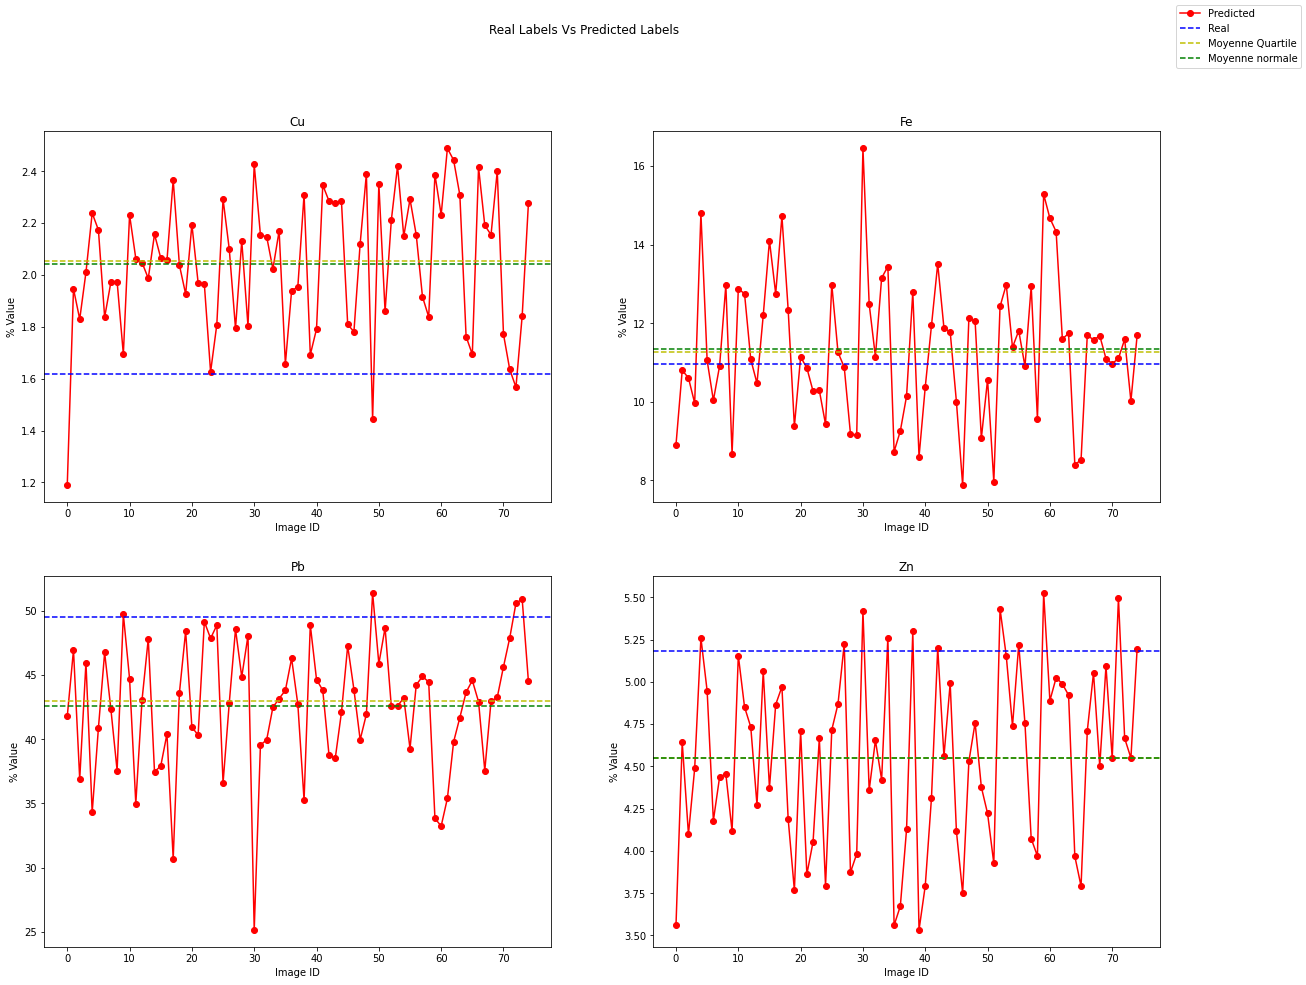

In [49]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [50]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.4347816719850126
Fe: 0.3154481733915482
Pb: 6.542350792098546
Zn: 0.629859756225227


XGBoost

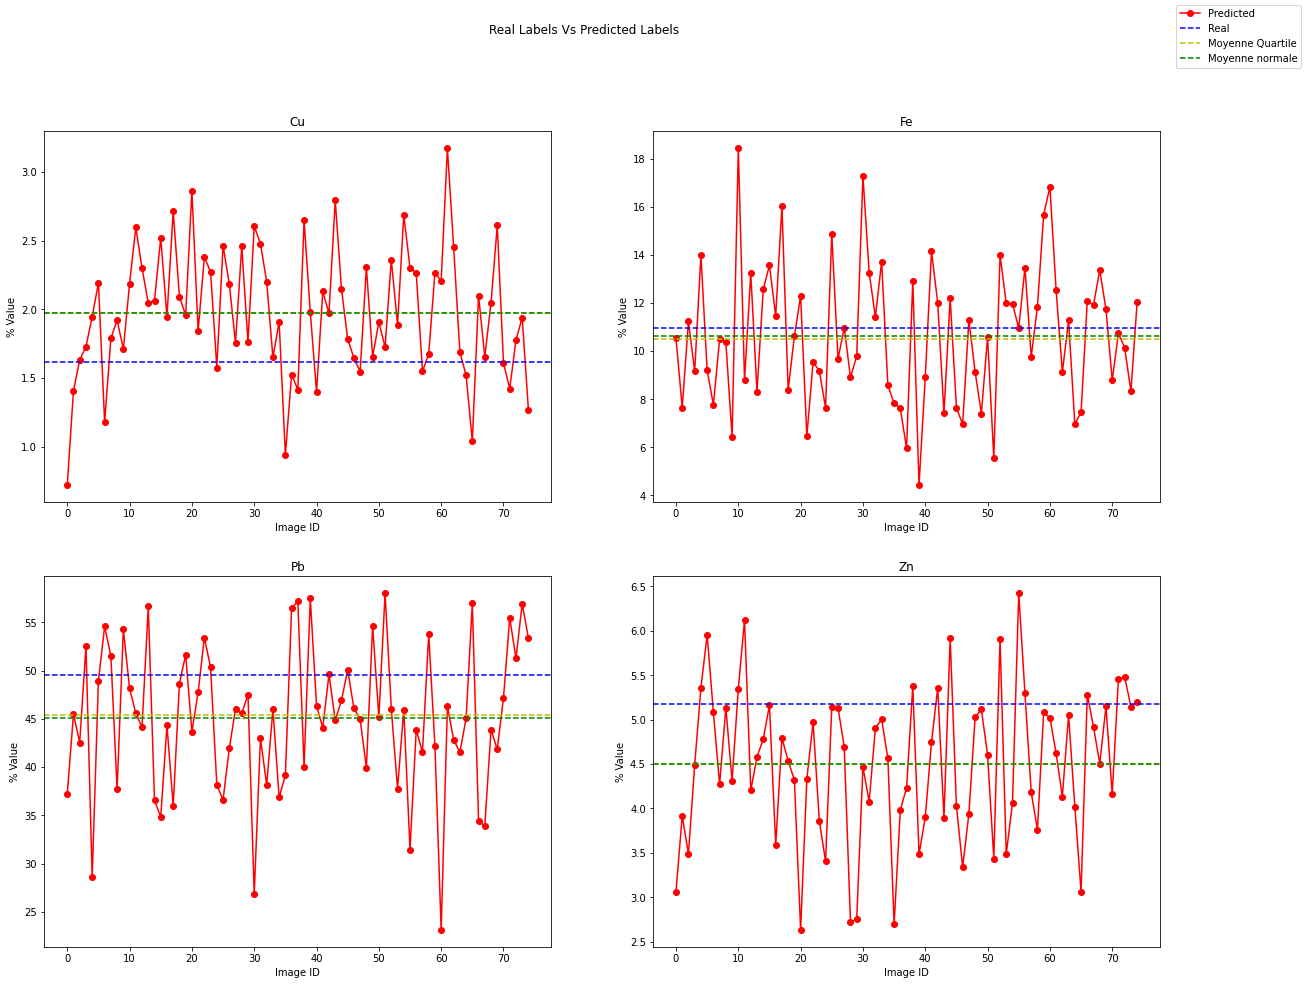

In [51]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [52]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.35431230545043935
Fe: 0.43250770568847585
Pb: 4.1701731872558625
Zn: 0.677941970825195


Catboost

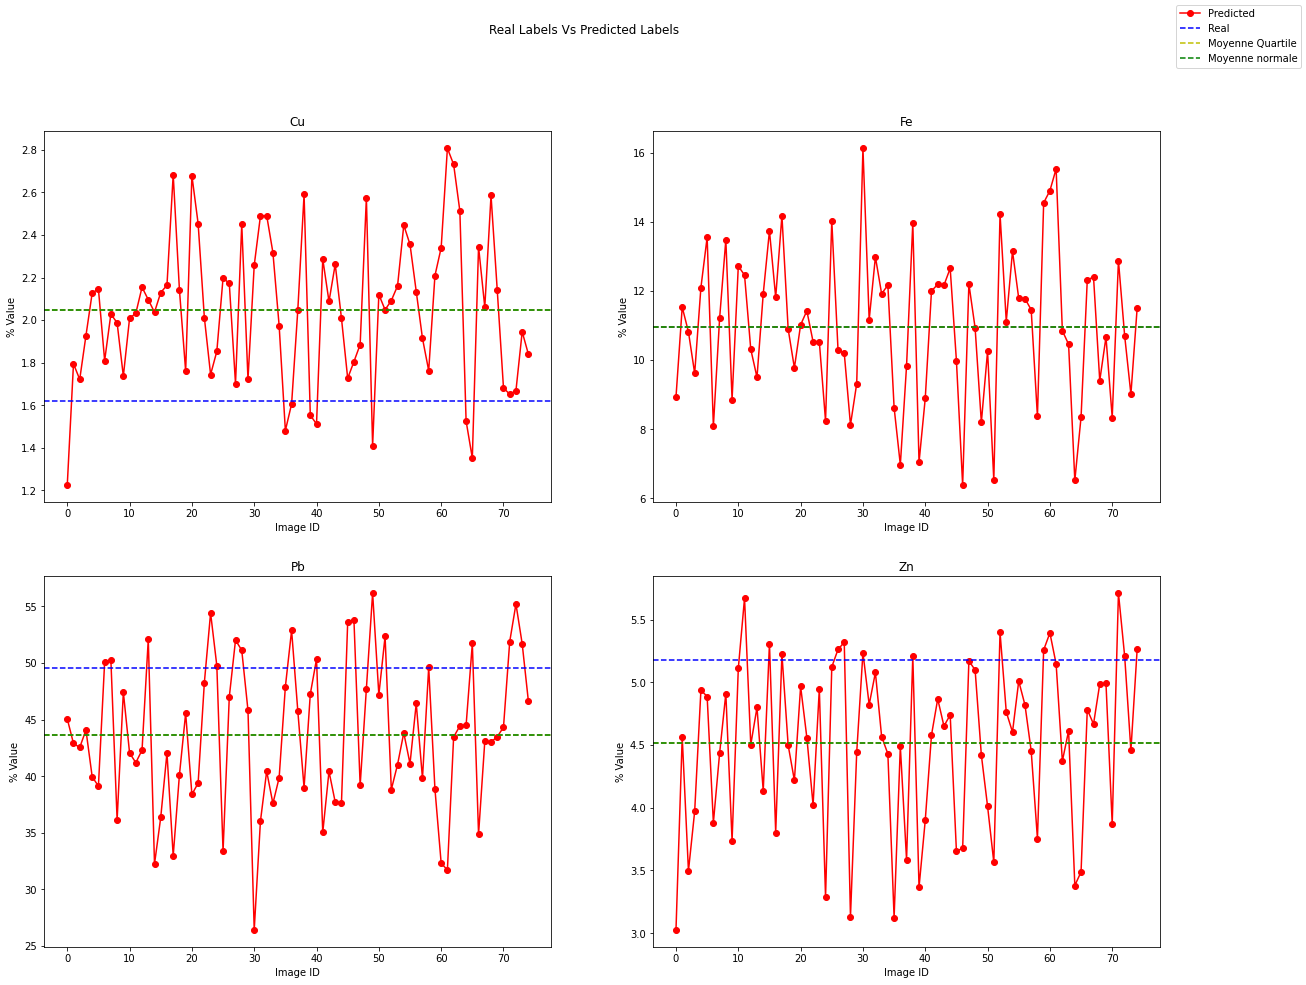

In [53]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [54]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.42656608159051235
Fe: 0.01599969835768711
Pb: 5.91795839538851
Zn: 0.6626791420581322


# Dep Video

In [53]:
msvm = pickle.load(open("./models/svm_model", 'rb'))
mxgb = pickle.load(open("./models/xgboost_model", 'rb'))
mcb = pickle.load(open("./models/catboost_model", 'rb'))
mrf = pickle.load(open("./models/random_forest_model", 'rb'))

In [54]:
TeunneurReel = TenneurReel("rl4_pb15-7.mp4", "DataSource.xlsx")

SVM

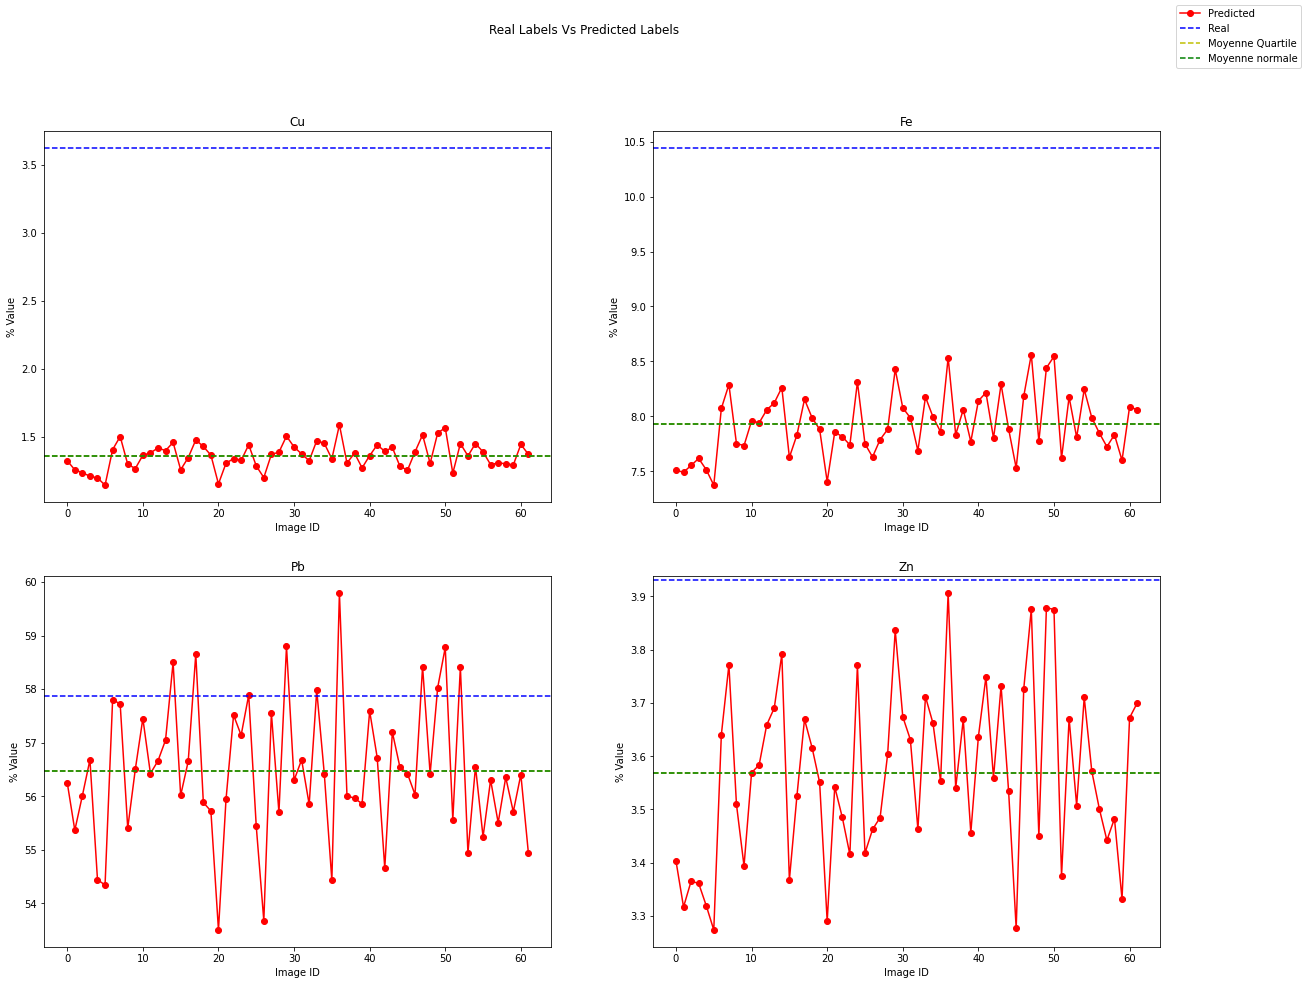

In [55]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Random Forest

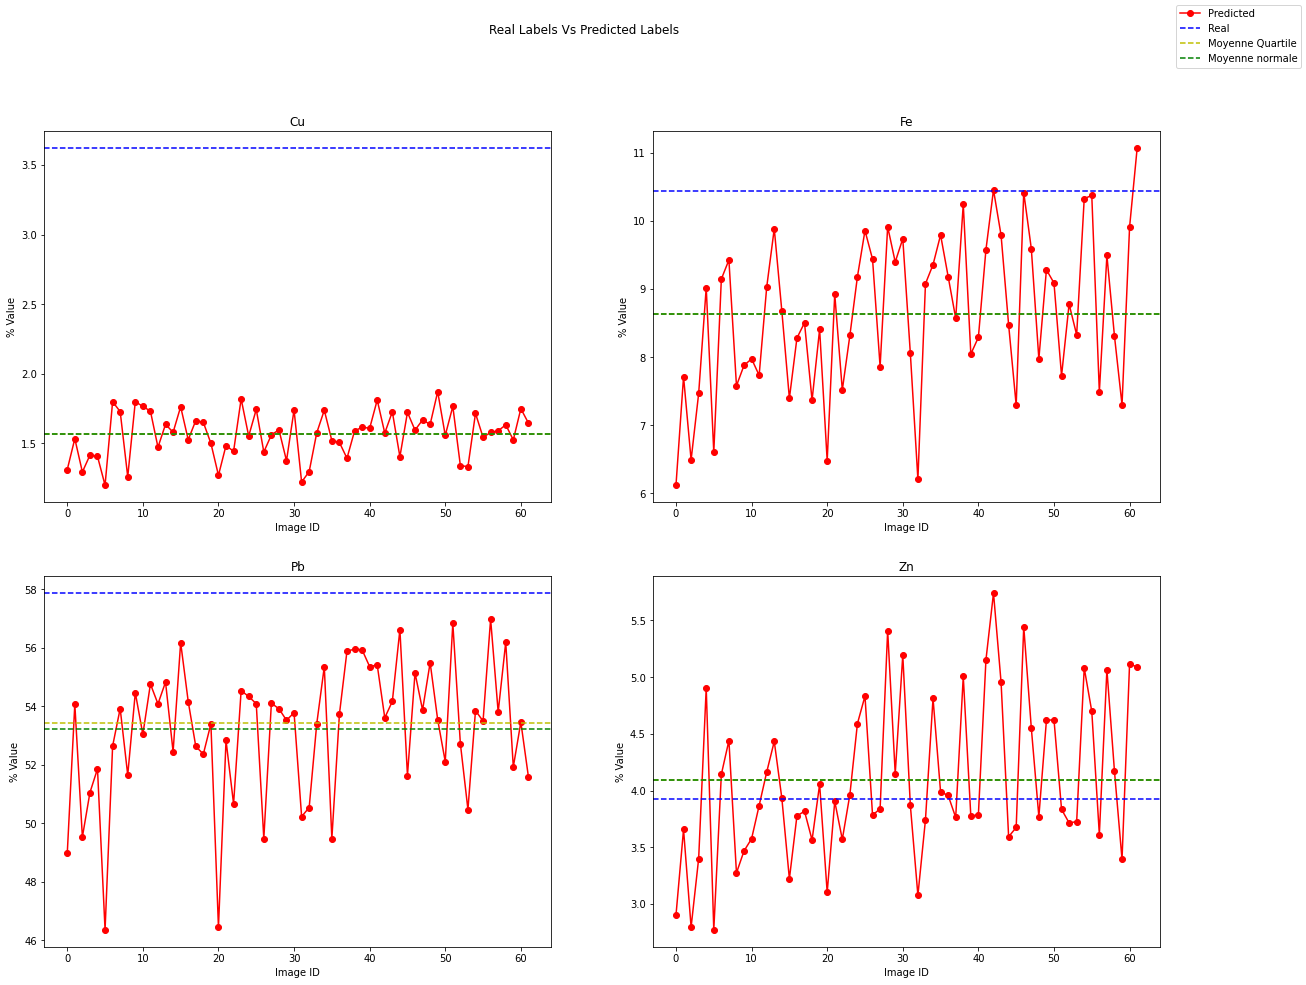

In [56]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

XGBoost

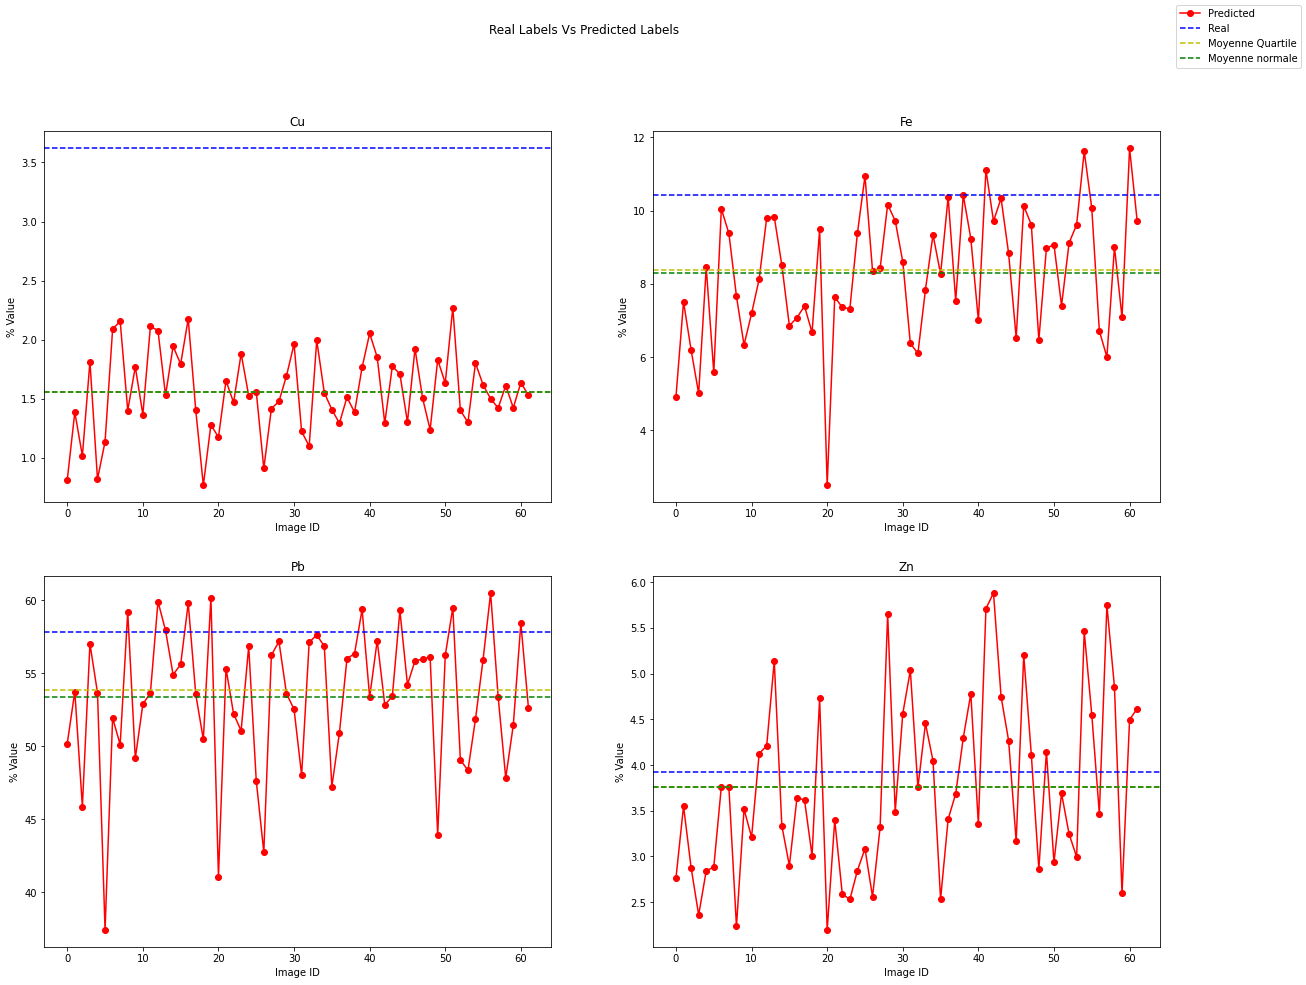

In [57]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Catboost

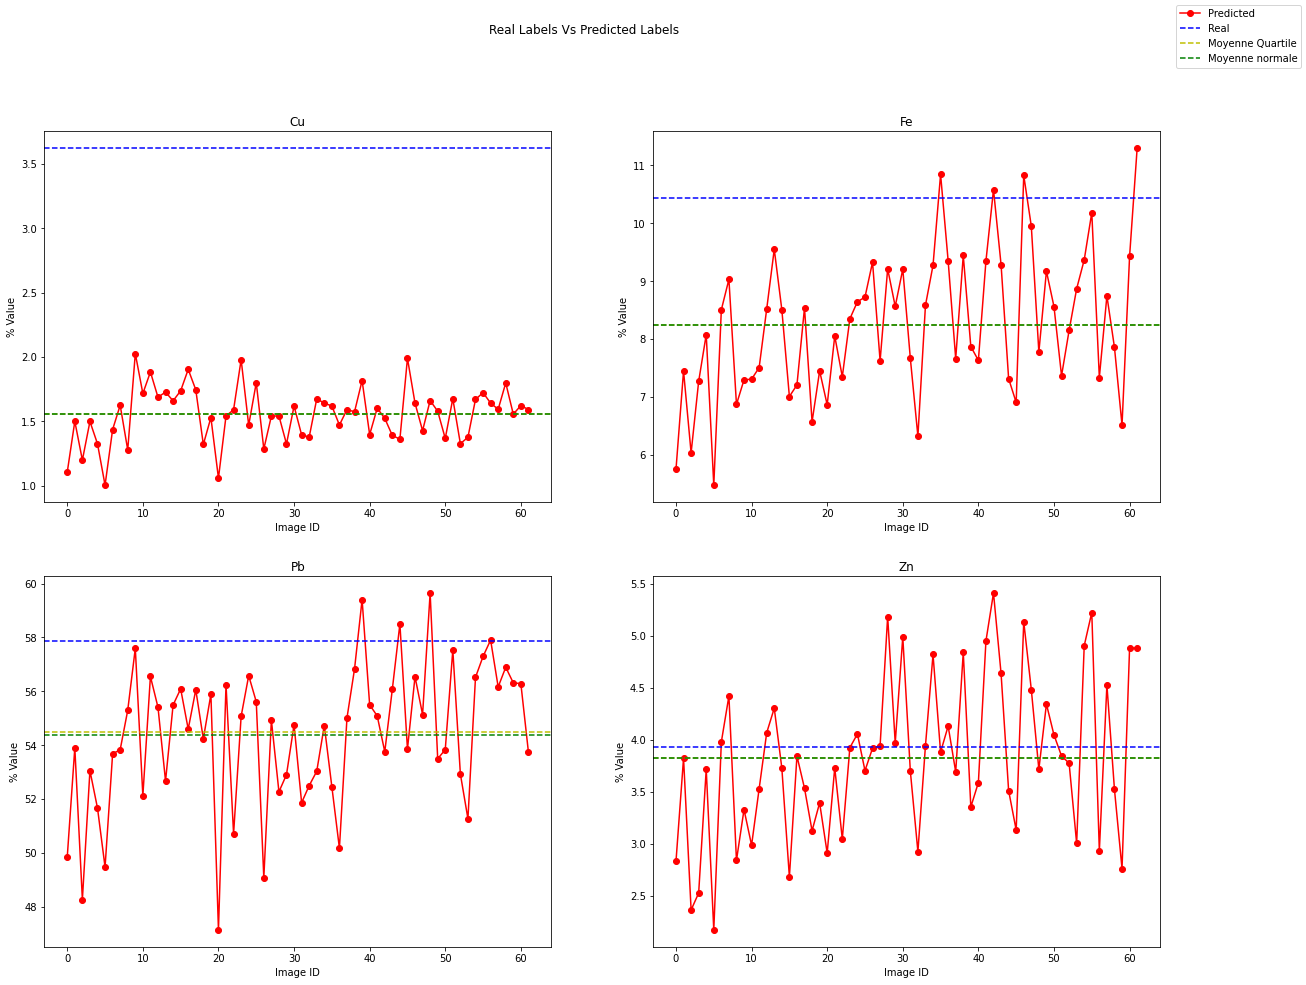

In [58]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

# All test videos average

In [311]:
test_videos = ["rl4_pb12-4.mp4", "rl1_pb16-4.mp4", "rl3_pb23-4.mp4", "rl1_pb9-5.mp4", "rl4_pb30-6.mp4"]
models = [msvm, mrf, mxgb, mcb]

In [312]:
final_results_df = pd.DataFrame(columns=["Model", "Cu", "Fe", "Pb", "Zn"])

In [313]:
for model in models:
    model_name = type(model.estimator).__name__
    avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
    for test_vid in test_videos:
        TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
        Teneur_predit = predict_video("../video_test/" + test_vid, model)
        Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
        avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
        avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
        avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
        avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
        print(model_name + " " + test_vid + " done")
    avgs_cu = np.mean(avgs_cu)
    avgs_fe = np.mean(avgs_fe)
    avgs_pb = np.mean(avgs_pb)
    avgs_zn = np.mean(avgs_zn)
    final_results_df = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

SVR rl4_pb12-4.mp4 done
SVR rl1_pb16-4.mp4 done
SVR rl3_pb23-4.mp4 done
SVR rl1_pb9-5.mp4 done
SVR rl4_pb30-6.mp4 done
RandomForestRegressor rl4_pb12-4.mp4 done
RandomForestRegressor rl1_pb16-4.mp4 done
RandomForestRegressor rl3_pb23-4.mp4 done
RandomForestRegressor rl1_pb9-5.mp4 done
RandomForestRegressor rl4_pb30-6.mp4 done
XGBRegressor rl4_pb12-4.mp4 done
XGBRegressor rl1_pb16-4.mp4 done
XGBRegressor rl3_pb23-4.mp4 done
XGBRegressor rl1_pb9-5.mp4 done
XGBRegressor rl4_pb30-6.mp4 done
CatBoostRegressor rl4_pb12-4.mp4 done
CatBoostRegressor rl1_pb16-4.mp4 done
CatBoostRegressor rl3_pb23-4.mp4 done
CatBoostRegressor rl1_pb9-5.mp4 done
CatBoostRegressor rl4_pb30-6.mp4 done


In [314]:
final_results_df

,Model,Cu,Fe,Pb,Zn
0,SVR,0.771880,4.085274,13.451297,1.207506
1,RandomForestRegressor,0.724051,3.338530,9.985208,1.307100
2,XGBRegressor,0.716596,3.261976,9.392847,1.306166
3,CatBoostRegressor,0.789521,3.142899,9.691680,1.212227
